# **Random Forest without Differential Evolution:**

In [1]:
import pandas as pd
import numpy as np 

In [2]:
df= pd.read_csv('C:\\Users\\MyMachine\\Desktop\\Fuzzy-Logic-Based-Maternal-Mental-Health-Risk-Assessment\\Feature_Engineering\\hybrid_matrix.csv')

In [3]:
df.shape

(20000, 82)

In [4]:
df.head()

,province_Gandaki,province_Karnali,province_Koshi,province_Lumbini,province_Madhesh,province_Sudurpashchim,ethnicity_Hill High Caste,ethnicity_Janajati,ethnicity_Muslim,ethnicity_Terai Caste,...,mu_isolation_high,mu_sleep_poor,mu_sleep_moderate,mu_sleep_good,mu_stress_low.1,mu_stress_mod.1,mu_stress_high.1,mu_distance_easy,mu_distance_moderate,mu_distance_difficult
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.00,0.466667,0.15,1.0,0.000000,0.0,0.420000,0.000000,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.7,0.85,0.120000,0.00,0.0,0.333333,0.0,0.056667,0.610000,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.2,0.00,0.733333,0.00,1.0,0.000000,0.0,0.000000,0.000000,1.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.15,0.680000,0.00,1.0,0.000000,0.0,0.000000,0.823333,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.3,0.30,0.560000,0.00,0.0,1.000000,0.0,0.940000,0.000000,0.0


--------

Random Forest is a good choice because it inherently handles the mix of binary, one-hot, and continuous-like (fuzzy) features without requiring extensive scaling.

The performance of the Random Forest depends critically on three main hyperparameters.

| Hyperparameter | Description | Best Initial Range/Value | Notes |
| :--- | :--- | :--- | :--- |
| $\text{n\_estimators}$ | The number of trees in the forest. | **[100, 500]** | More trees generally means better performance but increased training time. Start at 100 or 200. |
| $\text{max\_depth}$ | The maximum depth of the tree. | **[10, 30]** or **None** | Limits tree complexity, preventing overfitting. Start with a range or $\text{None}$ (full depth) and see if pruning helps. |
| $\text{min\_samples\_split}$ | The minimum number of samples required to split an internal node. | **[2, 5, 10]** | Higher values prevent overfitting by forcing the tree to look at larger patterns. |
| $\text{min\_samples\_leaf}$ | The minimum number of samples required to be at a leaf node. | **[1, 2, 4]** | Prevents the model from learning features specific to very few instances (overfitting). |
| $\text{max\_features}$ | The number of features to consider when looking for the best split. | **$\sqrt{N} \approx 9$** or **[0.1, 0.5]** (as a fraction) | Where $N=82$ (total features). The default $\sqrt{N}$ is often a good starting point for classification. |

**General Settings:**

  * **$\text{criterion}$:** Use **$\text{'gini'}$** (default) or $\text{'entropy'}$ (for information gain). The difference is often marginal, so stick with $\text{gini}$ unless tuning shows $\text{entropy}$ is significantly better.
  
  * **$\text{bootstrap}$:** Keep this at $\text{True}$ (the default). It's fundamental to the **random** nature of the forest.
  
  * **$\text{oob\_score}$:** Set to $\text{True}$. This calculates the out-of-bag R-squared score, providing a free, unbiased validation estimate without needing a separate cross-validation set.

**Optimal Training Strategy:**

Given that your target feature, $\text{'ppd\_risk\_level'}$, is ordinal with three classes ('No/Minimal Risk', 'Possible Depression', 'Probable Depression'), it's crucial to ensure a balanced representation of these classes during training and validation.

**1\. Data Split Method: Stratified Train-Test Split:**

  * **Action:** Before any cross-validation, split your data into an initial **Train Set** and a held-out **Test Set** (e.g., $70/30$ or $80/20$).
  
  * **Key Requirement:** Use $\text{stratified}$ sampling based on the **target variable** ($\text{ppd\_risk\_level}$).
  
  * **Benefit:** This guarantees that the proportion of each $\text{ppd\_risk\_level}$ class is the same in both the training set and the final test set, providing a reliable measure of generalization performance.

**2\. Hyperparameter Tuning: Stratified Cross-Validation (CV):**

  * **Tuning Strategy:** Use **$\text{GridSearchCV}$** or **$\text{RandomizedSearchCV}$** for exploring the hyperparameter space.
  * **Cross-Validation:** Implement **$\text{Stratified K-Fold Cross-Validation}$** (e.g., $K=5$ or $K=10$) on the **Training Set** only.
  * **Benefit:** Since the training data is split into $K$ folds for tuning, stratifying the folds ensures each validation fold maintains the class balance, leading to more stable hyperparameter selection.

**3\. Evaluation Metric: F1-Score (Macro or Weighted):**

Since this is a classification problem with potential class imbalance (even with stratification, the raw counts might be uneven), using **Accuracy** alone is insufficient.

  * **Metric Choice:** Use the **F1-score** (or $\text{ROC AUC}$ if probabilities are important).
      * For a balanced view across all three classes, use **$\text{f1\_score}$** with $\text{average='macro'}$.
      * If you want to emphasize the model's performance on the majority class, use $\text{average='weighted'}$.

**Best Possible Combination:**

The best combination involves the most efficient tuning strategy paired with robust validation.

| Step | Technique | Rationale |
| :--- | :--- | :--- |
| **Data Preparation** | **Stratified Train-Test Split** | Ensures the final performance metric is based on a distributionally representative test set. |
| **Tuning Method** | **$\text{RandomizedSearchCV}$** | More efficient than Grid Search for large parameter spaces; quickly finds near-optimal solutions. |
| **CV Method** | **Stratified K-Fold ($\text{K} \geq 5$)** | Robustly tunes hyperparameters by preserving class balance in every validation fold. |
| **Model** | **$\text{RandomForestClassifier}$** | Excellent default choice for hybrid/mixed feature types and high dimensionality ($\text{N=82}$). |
| **Metric** | **$\text{F1-score (Macro)}$** | Provides a single metric that balances precision and recall across all three PPD risk levels. |

```python
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None], # None means grow trees fully
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.1, 0.5]
}
```

Using $\text{RandomizedSearchCV}$ with this dictionary and $5$-fold stratified cross-validation is the most effective approach.

-----
------
-----------
-----------
------

## **Basic Random Forest Model**

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

In [6]:
df.columns

Index(['province_Gandaki', 'province_Karnali', 'province_Koshi',
       'province_Lumbini', 'province_Madhesh', 'province_Sudurpashchim',
       'ethnicity_Hill High Caste', 'ethnicity_Janajati', 'ethnicity_Muslim',
       'ethnicity_Terai Caste', 'occupation_Clerical', 'occupation_Manual',
       'occupation_Professional/Technical/Managerial',
       'occupation_Sales/Service', 'delivery_type_Cesarean',
       'delivery_type_Normal', 'baby_health_status_Major issues',
       'baby_health_status_Minor issues', 'mental_health_awareness_Low',
       'mental_health_awareness_Medium', 'residence',
       'caste_discrimination_exposure', 'family_type', 'birth_complications',
       'previous_pregnancy_loss', 'health_insurance',
       'previous_mental_health_consultation', 'ppd_risk_level', 'mu_age_young',
       'mu_age_prime', 'mu_age_advanced', 'mu_edu_low_risk',
       'mu_edu_medium_risk', 'mu_edu_high_risk', 'mu_wealth_high_poverty',
       'mu_wealth_medium_wealth', 'mu_wealth_low_po

In [7]:
df.shape

(20000, 82)

In [8]:
target_feature= "ppd_risk_level"

In [9]:
# Separate Features (X) and Target (y):

# Assuming the features are all columns except 'ppd_risk_level'.
X = df.drop(columns=[target_feature])

In [10]:
X.shape

(20000, 81)

In [11]:
y_original = df[[target_feature]]
y_original

,ppd_risk_level
0,0
1,2
2,0
3,0
4,1
...,...
19995,0
19996,0
19997,0
19998,1


In [12]:
# Stratified Train-Test Split (80/20 split recommended for initial training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_original, test_size =0.2, random_state =42, stratify =y_original)

In [13]:
X_train.shape, X_test.shape

((16000, 81), (4000, 81))

In [14]:
y_train.shape, y_test.shape

((16000, 1), (4000, 1))

**Random Forest Model Training:**

We train the $\text{RandomForestClassifier}$ directly using reasonable initial parameters. We use $\text{class\_weight='balanced'}$ to handle potential inherent class imbalance in the PPD risk levels.

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=500,            # A decent number of trees
    max_depth=20,                # Limit depth to prevent severe overfitting
    random_state=42,
    class_weight='balanced',     # Adjusts weights inversely proportional to class frequencies
    n_jobs=-1                    # Use all processor cores for faster training
)
 
print("Starting Random Forest Model Training...")
rf_model.fit(X_train, y_train)
print("Training Complete.")

Starting Random Forest Model Training...


c:\Users\MyMachine\Desktop\Fuzzy-Logic-Based-Maternal-Mental-Health-Risk-Assessment\env\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training Complete.


**Prediction and Performance Metrics:**

Now we evaluate the model's performance on the held-out test sample, calculating the required metrics.

In [16]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

In [17]:
# Make Predictions on the Test Set
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

In [18]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")

Test Set Accuracy: 0.8745


In [19]:
# Precision, Recall, F1-Score (Weighted Average)
precision_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Weighted Metrics (Considers class size):")
print(f"Precision (Weighted): {precision_w:.4f}")
print(f"Recall (Weighted): {recall_w:.4f}")
print(f"F1-Score (Weighted): {f1_w:.4f}")

Weighted Metrics (Considers class size):
Precision (Weighted): 0.8759
Recall (Weighted): 0.8745
F1-Score (Weighted): 0.8735


In [20]:
# AUC-ROC (One-vs-Rest for multi-class)
auc_roce = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f"AUC-ROC (One-vs-Rest, Weighted): {auc_roce:.4f}")

AUC-ROC (One-vs-Rest, Weighted): 0.9699


In [21]:
y_test.value_counts()

ppd_risk_level
0                 1630
1                 1618
2                  752
Name: count, dtype: int64

In [22]:
target_feature = 'ppd_risk_level'

ppd_order = ['No/Minimal Risk', 'Possible Depression', 'Probable Depression']

In [23]:
# Full Classification Report:
target_names = ppd_order
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

Detailed Classification Report:
                     precision    recall  f1-score   support

    No/Minimal Risk       0.91      0.94      0.93      1630
Possible Depression       0.83      0.87      0.85      1618
Probable Depression       0.90      0.74      0.81       752

           accuracy                           0.87      4000
          macro avg       0.88      0.85      0.86      4000
       weighted avg       0.88      0.87      0.87      4000



**Confusion Matrix Visualization:**   
The confusion matrix shows how many observations were correctly/incorrectly classified for each PPD risk level.

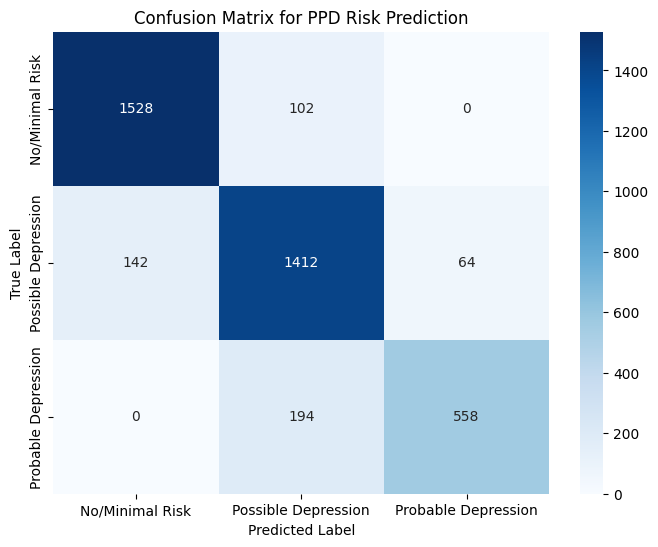

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
target_names = ppd_order

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Confusion Matrix for PPD Risk Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

**Feature Importance Visualization:**  
The Random Forest provides a measure of feature importance based on the reduction in impurity (Gini importance) across all trees.

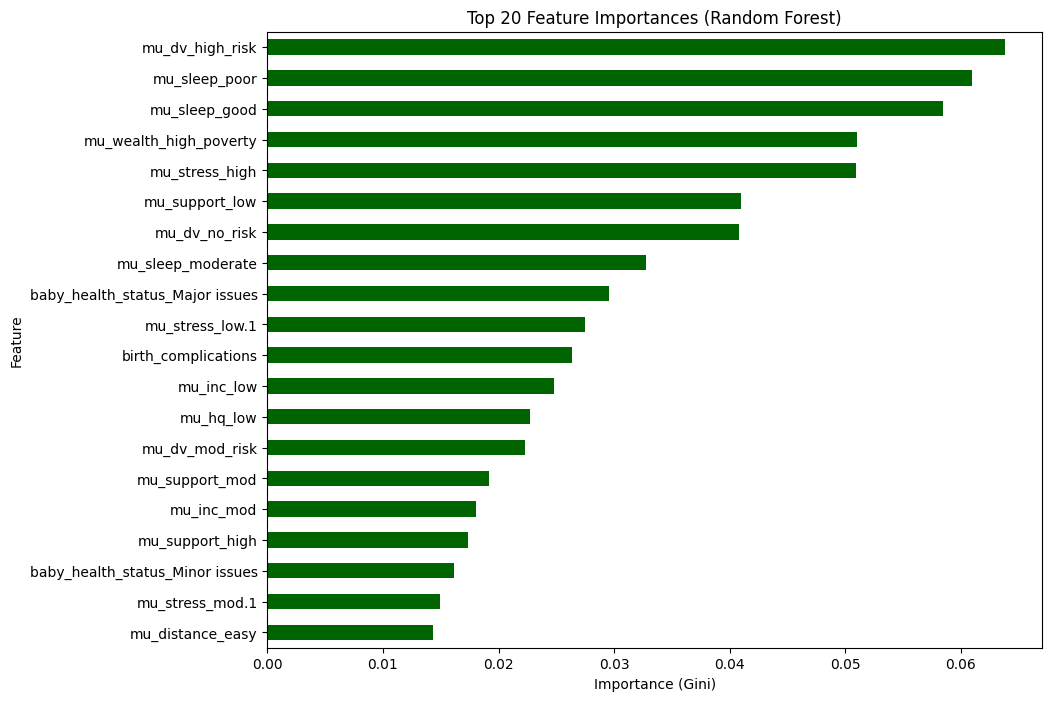

In [48]:
# Get feature names and importances
feature_names = X_train.columns
importances = rf_model.feature_importances_

# Create a Series and sort
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Display Top 20 Features
plt.figure(figsize=(10, 8))
feature_importances.head(20).plot(kind='barh', color='darkgreen')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance (Gini)')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

-------------
------
-----------------

## **Hyperparameters Tuning and Model Optimzation::**

We will use $\text{RandomizedSearchCV}$ with **Stratified K-Fold** on our training data ($X_{\text{train}}, y_{\text{train}}$) to efficiently explore the hyperparameter space.


We'll define the hyperparameter search space (`param_dist`) and the cross-validation strategy (`cv`).

In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [27]:
# Define the Parameter Distribution to Search: 
# This dictionary contains the different hyperparameter values to be tested.
param_dist = {
    'n_estimators': [100, 200, 500], # Number of trees
    'max_depth': [10, 20, 30, None], # Max depth of trees
    'min_samples_split': [2, 5, 10], # Min samples required to split a node
    'min_samples_leaf': [1, 2, 4],   # Min samples required at a leaf node
    'max_features': ['sqrt', 0.1, 0.5] # Features to consider for best split
}

In [ ]:
# Define the Cross-Validation Strategy:
# Use Stratified K-Fold to maintain class proportions in each of the 10 folds.
N_SPLITS = 10 #5
stratified_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

In [29]:
# Initialize the Base Model
# Use class_weight='balanced' to handle potential imbalance during CV.
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

We set up $\text{RandomizedSearchCV}$ to sample a specified number of combinations (`n_iter`) from the `param_dist`. We use **F1-score (macro)** as the scoring metric because it balances precision and recall across all three PPD risk levels equally, which is crucial for a multi-class problem.

In [ ]:
# Initialize Randomized Search
N_ITER_SEARCH = 50 # Number of parameter settings that are sampled (adjust based on time/resources)
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    scoring='f1_macro', # Metric to optimize for (F1-score across all classes)
    cv=stratified_cv,
    verbose=2, # Verbosity level
    random_state =42,
    n_jobs=-1 # Use all cores
)

In [31]:
# Execute the Search on the Training Data
print(f"Starting Randomized Search with {N_ITER_SEARCH} iterations and {N_SPLITS}-Fold Stratified CV...")
random_search.fit(X_train, y_train)
print("Search Complete.")

Starting Randomized Search with 50 iterations and 10-Fold Stratified CV...
Fitting 10 folds for each of 50 candidates, totalling 500 fits


c:\Users\MyMachine\Desktop\Fuzzy-Logic-Based-Maternal-Mental-Health-Risk-Assessment\env\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Search Complete.


In [32]:
# Retrieve the Best Model and Parameters:
best_rf_model = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_

print("\n--- Optimized Model Results ---")
print(f"Best CV F1-Score (Macro): {best_score:.4f}")
print("Best Hyperparameters Found:")
print(best_params)


--- Optimized Model Results ---
Best CV F1-Score (Macro): 0.8912
Best Hyperparameters Found:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


**Final Model Evaluation on the Test Set:**

The $\text{best\_rf\_model}$ found by $\text{RandomizedSearchCV}$ is already trained on the entire training set using the optimal hyperparameters. We now use the completely unseen **test set** ($X_{\text{test}}, y_{\text{test}}$) for the final, unbiased evaluation.

In [33]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Prediction on the Test Set
y_pred_optimized = best_rf_model.predict(X_test)
y_proba_optimized = best_rf_model.predict_proba(X_test)

In [34]:
# Final Metrics
accuracy = accuracy_score(y_test, y_pred_optimized)
f1_w = f1_score(y_test, y_pred_optimized, average='weighted', zero_division=0)
auc_roce = roc_auc_score(y_test, y_proba_optimized, multi_class='ovr', average='weighted')
target_names = ppd_order

print("Final Optimized Model Performance (Test Set)")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1_w:.4f}")
print(f"AUC-ROC (Weighted): {auc_roce:.4f}")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_optimized, target_names=target_names, zero_division=0))

Final Optimized Model Performance (Test Set)
Accuracy: 0.8998
F1-Score (Weighted): 0.8990
AUC-ROC (Weighted): 0.9807
Detailed Classification Report:
                     precision    recall  f1-score   support

    No/Minimal Risk       0.93      0.96      0.95      1630
Possible Depression       0.88      0.88      0.88      1618
Probable Depression       0.88      0.81      0.84       752

           accuracy                           0.90      4000
          macro avg       0.90      0.88      0.89      4000
       weighted avg       0.90      0.90      0.90      4000



**Visualizing Optimized Model Results:**

**Confusion Matrix of the Optimized Model:**    
This visualization will show if the hyperparameter tuning improved the classification accuracy, especially for the minority classes (e.g., 'Probable Depression').

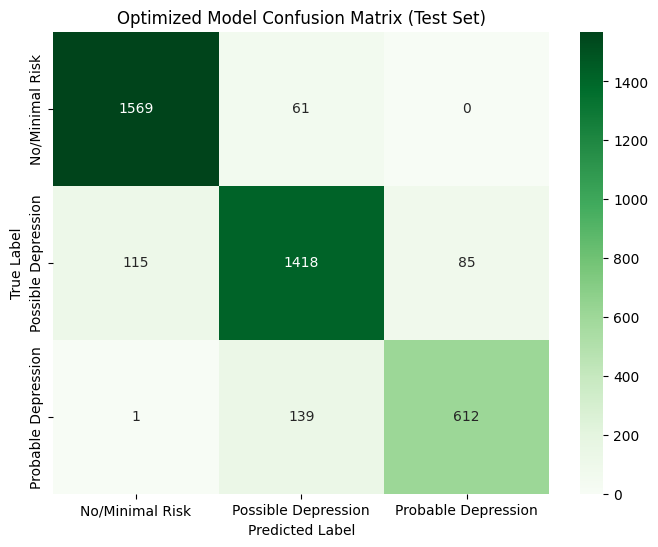

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

conf_mat_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_mat_optimized,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Optimized Model Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

**Feature Importance from the Optimized Model:**   
Feature importances are often more stable and reliable when derived from an optimized model.

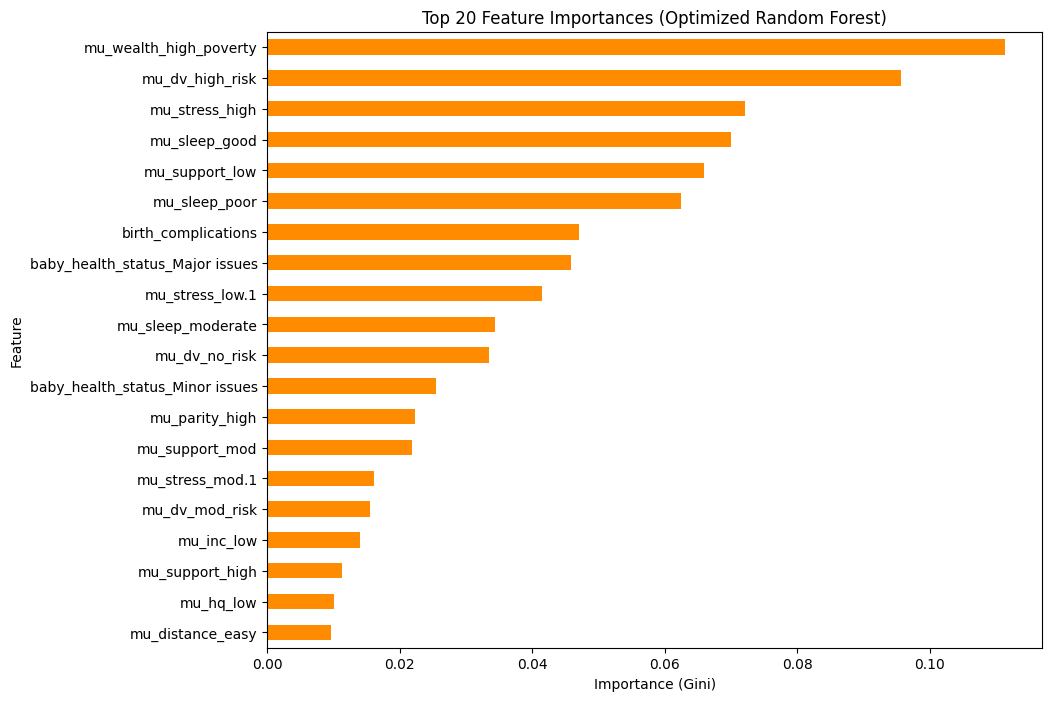

In [36]:
# Get feature names and importances from the best model
feature_names = X_train.columns
importances_optimized = best_rf_model.feature_importances_

# Create a Series and sort
feature_importances_optimized = pd.Series(importances_optimized, index=feature_names).sort_values(ascending=False)

# Display Top 20 Features
plt.figure(figsize=(10, 8))
feature_importances_optimized.head(20).plot(kind='barh', color='darkorange')
plt.title('Top 20 Feature Importances (Optimized Random Forest)')
plt.xlabel('Importance (Gini)')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

------
-----

#### **Saving the Optimized Model with Joblib:**

We use the `joblib.dump()` function to efficiently serialize the trained model object (`best\_rf\_model`) into a file.

In [37]:
from joblib import dump
import os

# We have: 
# Retrieve the Best Model and Parameters:
best_rf_model = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_

print("\n--- Optimized Model Results ---")
print(f"Best CV F1-Score (Macro): {best_score:.4f}")
print("Best Hyperparameters Found:")
print(best_params)


--- Optimized Model Results ---
Best CV F1-Score (Macro): 0.8912
Best Hyperparameters Found:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


In [38]:
# Define the filename for the saved model
model_filename = 'cv_optimized-rf_model_NO_DE.joblib'

try:
    # Use joblib.dump() to save the model. This is preferred over pickle for scikit-learn objects.
    dump(best_rf_model, model_filename)
    
    # Check the file size to confirm save
    file_size = os.path.getsize(model_filename) / (1024 * 1024)
    
    print(f"Optimized model successfully saved to '{model_filename}' using joblib.")
    print(f"File Size: {file_size:.2f} MB")

except Exception as e:
    print(f"An error occurred while saving the model: {e}")

Optimized model successfully saved to 'cv_optimized-rf_model_NO_DE.joblib' using joblib.
File Size: 95.09 MB


**Loading the Model with Joblib:**

To use the model., we'll use the `joblib.load()` function to quickly deserialize the file back into a Python object.

In [39]:
from joblib import load
import os

# Define the filename used for saving
model_filename = 'cv_optimized-rf_model_NO_DE.joblib'

# Check if the file exists before attempting to load
if os.path.exists(model_filename):
    try:
        # Load the model back into a new variable
        loaded_model_joblib = load(model_filename)
        
        print(f"✅ Model successfully loaded from '{model_filename}' using joblib.")
        print(f"Loaded Model Type: {type(loaded_model_joblib)}")
        
    except Exception as e:
        print(f"An error occurred while loading the model: {e}")

else:
    print(f"❌ Error: Model file '{model_filename}' not found.")

✅ Model successfully loaded from 'cv_optimized-rf_model_NO_DE.joblib' using joblib.
Loaded Model Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


**Using the Loaded Model for Prediction:**

The `loaded\_model\_joblib` object is now a functional $\text{RandomForestClassifier}$ instance, ready to be used on new data (`X_new`) for predictions.

In [40]:
# --- Hypothetical New Data ---
# Use the first few rows of the test set as 
# a placeholder for new, unseen data
X_new = X_test.head(5) 

In [41]:
X_new.shape

(5, 81)

In [42]:
# Use the loaded model to predict on new data
new_predictions = loaded_model_joblib.predict(X_new)

In [44]:
new_predictions

array([2, 0, 2, 0, 2])

In [47]:
# comparision: 
y_test.head(5)["ppd_risk_level"]

7492     2
3804     0
17484    2
11591    0
19204    2
Name: ppd_risk_level, dtype: int64

**Exact Match!**

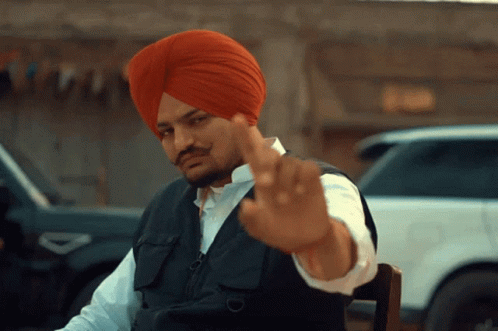